# Module 5 Homework: Chapter 6 Exercises

## Ryan Waterman
## 8/8/2025

# Problem 9

In this exercise, we will predict the number of applications received using the other variables in the College data set.

In [1114]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from random import randint, seed
from ISLP import load_data
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from ISLP.models import ModelSpec as MS
from functools import partial
from ISLP.models import Stepwise, sklearn_selected, sklearn_selection_path

warnings.filterwarnings('ignore')

In [1115]:
college = load_data('College')

### Dataset Information

Statistics for a large number of US Colleges from the 1995 issue of US News and World Report.

Private: A factor with levels No and Yes indicating private or public university

Apps: Number of applications received

Accept: Number of applications accepted

Enroll: Number of new students enrolled

Top10perc: Pct. new students from top 10% of H.S. class

Top25perc: Pct. new students from top 25% of H.S. class

F.Undergrad: Number of fulltime undergraduates

P.Undergrad: Number of parttime undergraduates

Outstate: Out-of-state tuition

Room.Board: Room and board costs

Books: Estimated book costs

Personal: Estimated personal spending

PhD: Pct. of faculty with Ph.D.’s

Terminal: Pct. of faculty with terminal degree

S.F.Ratio: Student/faculty ratio

perc.alumni: Pct. alumni who donate

Expend: Instructional expenditure per student

Grad.Rate: Graduation rate

In [1116]:
college.head(5)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## Part A

Split the data set into a training set and a test set.

In [1117]:
def split_data(data, train_perc:int):
    seed(42)
    train_indices = []
    test_indices = []

    for i in data.index.values:
        rand_num = randint(1,100)
        if rand_num <= train_perc:
            train_indices.append(i)
        else:
            test_indices.append(i)

    training_data = data.iloc[train_indices]
    test_data = data.iloc[test_indices]
    
    return training_data, test_data

In [1118]:
qauntitative = set(college.describe().columns)
categorical = set(college.columns) - qauntitative

cat_counts = {}

for var in categorical:
    cat_counts[var] = [[cat for cat in college[var].unique()], [i for i in range(len(college[var].unique()))]]


In [1119]:
for key, val in cat_counts.items():
    college[key].replace(val[0], val[1], inplace = True)

In [1120]:
college['Private'] = college['Private'].cat.codes

In [1121]:
college.dtypes

Private           int8
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD              int64
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [1122]:
college.head(5)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [1123]:
training_data, test_data = split_data(college, 65)

print(len(training_data), len(test_data))

501 276


## Part B

Fit a linear model using least squares on the training set, and report the test error obtained.

#### Notes

1. Prediction Accuracy in Linear Models for data sets where the relationship between response and predictor are approximately linear depends on the ratio between the number of observations (n) and predictors (p). High n:p have lower variance and perform better on test data. Low n:p can have higher variability in the least squares fit, leading to poor predictions on novel data. If p>n, there is no longer a least squares coefficient estimate, and the model will have extremely high variance. These issues can be mitigated by shrinking p for data sets with low n:p.
2. Best Subset Selection:
     - Compares the R<sup>2</sup> of the null model to the R<sup>2</sup> of all models with k predictors, up to p. The best of model for each k is *M*<sub>*k*</sub>, and then all *M*<sub>*k*</sub> models are compared using prediction error on a validation set, *C*<sub>*p*</sub>, AIC, BIC, Adjusted R<sup>2</sup>, or Cross-Validation.
3. Forward Stepwise Selection:
    - Let *M*<sub>*0*</sub> denote the null model, which contains no predictors.
    - For k = 0 , . . . , p −1:
        1. Consider all p − k models that augment the predictors in *M*<sub>*k*</sub> with one additional predictor.
        2. Choose the best among these p − k models, and call it *M*<sub>*k+1*</sub>. Here best is defined as having smallest RSS or highest R<sup>2</sup>.
    - Select a single best model from among *M*<sub>*0*</sub>, . . . , *M*<sub>*p*</sub> using the prediction error on a validation set, *C*<sub>*p*</sub>, (AIC), BIC, adjusted R<sup>2</sup>, or use the cross-validation method.
4. Backward Stepwise Selection:
    - Let *M*<sub>*p*</sub> denote the full model, which contains all p predictors.
    - For k = p, p −1, . . . , 1:
        1. Consider all k models that contain all but one of the predictors in *M*<sub>*k*</sub>, for a total of k −1 predictors.
        2. Choose the best among these k models, and call it *M*<sub>*k-1*</sub>. Here best is defined as having smallest RSS or highest R<sup>2</sup>.
    3. Select a single best model from among M0, . . . , Mp using the prediction error on a validation set, *C*<sub>*p*</sub>, (AIC), BIC, or adjusted R<sup>2</sup>. Or use the cross-validation method.
5. Training set MSE is generally an under-estimate of test MSE.
6. For a fitted least squares model with *d* predictors, the *C*<sub>*p*</sub> estimate of test MSE is computed using:

    ![img](c_p.png)

    where σ_hat<sup>2</sup> is an estimate of the variance of the error ε associated with each response measurement. Typically σ_hat<sup>2</sup> is estimated using the full model containing all predictors.

7. AIC is described by the equation, below:

    ![img](aic.png)

    For least squares models, *C*<sub>*p*</sub> and AIC are proportional.
 
8. BIC is described by the equation, below:

    ![img](bic.png)

    BIC generally places a heavier penalty on models with many variables.



#### Fitting Least Squares Model and Determining Test Error

Estimating the Test Error will be done using *C*<sub>*p*</sub>

In [1124]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic is used because sklearn maximizes scores."
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n


Determine σ_hat<sup>2</sup> of the training data set with all predictors.

In [1125]:
design = MS(training_data.columns.drop('Apps')).fit(training_data)

Y = np.array(training_data['Apps'])
X = design.transform(training_data) 

m_0 = sm.OLS(Y, X).fit()
sigma2 = m_0.scale
sigma2

np.float64(1213004.7227305942)

Freeze the nCp scorer and σ_hat<sup>2</sup> variable.

In [1126]:
neg_Cp = partial(nCp, sigma2)

Utilize a forward stepwise selection algorithm to determine the best model.

In [1127]:
strategy = Stepwise.first_peak(design,
                                direction='forward',
                                max_terms=len(design.terms))

In [1128]:
training_MSE = sklearn_selected(sm.OLS,
                                    strategy)
training_MSE.fit(training_data, Y)
training_MSE.selected_state_

('Accept',
 'Books',
 'Enroll',
 'Expend',
 'F.Undergrad',
 'Grad.Rate',
 'Outstate',
 'P.Undergrad',
 'Personal',
 'PhD',
 'Private',
 'Room.Board',
 'S.F.Ratio',
 'Terminal',
 'Top10perc',
 'Top25perc',
 'perc.alumni')

In [1129]:
training_Cp = sklearn_selected(sm.OLS,
                                strategy,
                                scoring=neg_Cp)
training_Cp.fit(training_data, Y)
training_Cp.selected_state_

('Accept',
 'Enroll',
 'Expend',
 'Grad.Rate',
 'Outstate',
 'Personal',
 'PhD',
 'Private',
 'Room.Board',
 'Top10perc',
 'Top25perc')

Calculate MSE based on each model's predictions using the mean_squared_error function.

In [1130]:
test_y = test_data['Apps']
test_X = test_data.drop('Apps', axis = 1)

test_Cp = nCp(sigma2, training_Cp, test_X, test_y)
test_Cp

np.float64(-1119369.1048870299)

In [1131]:
from sklearn.metrics import mean_squared_error

In [1132]:
y_pred_training_mse = training_MSE.predict(test_X)
mean_squared_error(test_y, y_pred_training_mse)

975927.5291572117

In [1133]:
y_pred_training_Cp = training_Cp.predict(test_X)
mean_squared_error(test_y, y_pred_training_Cp)

969940.9868694929

## Part C

Fit a ridge regression model on the training set, with λ chosen by cross-validation. Report the test error obtained.

In [1134]:
import sklearn.linear_model as skl
from sklearn.pipeline import Pipeline
import sklearn.model_selection as skm
from sklearn.preprocessing import StandardScaler

In [1135]:
X = training_data[list(training_Cp.selected_state_)]
Y = training_data['Apps']

Xs = X - np.array(X.mean(0))[None,:]
X_scale = X.std(0)
Xs = Xs / np.array(X_scale)[None,:]
lambdas = 10**np.linspace(8, -2, 100) / Y.std()

soln_array = skl.ElasticNet.path(Xs,
                                Y,
                                l1_ratio=0.,
                                alphas=lambdas)[1]

In [1136]:
soln_path = pd.DataFrame(soln_array.T,
                        columns=X.columns,
                        index=lambdas)
soln_path.index.name = 'lambda'
soln_path

,Accept,Enroll,Expend,Grad.Rate,Outstate,Personal,PhD,Private,Room.Board,Top10perc,Top25perc
lambda,,,,,,,,,,,
24554.080710,0.155207,0.139240,0.047655,0.029421,0.015016,0.027706,0.066267,-0.065591,0.028566,0.063159,0.063665
19458.689048,0.195845,0.175696,0.060131,0.037123,0.018947,0.034960,0.083615,-0.082764,0.036045,0.079693,0.080332
15420.678295,0.247120,0.221695,0.075873,0.046841,0.023906,0.044113,0.105504,-0.104433,0.045481,0.100556,0.101361
12220.623830,0.311817,0.279735,0.095733,0.059102,0.030161,0.055662,0.133121,-0.131773,0.057386,0.126878,0.127894
9684.635392,0.393447,0.352965,0.120791,0.074571,0.038053,0.070233,0.167964,-0.166269,0.072405,0.160086,0.161368
...,...,...,...,...,...,...,...,...,...,...,...
0.000006,4135.853559,-663.728253,388.430933,189.494264,-384.279002,103.556243,-157.117768,-255.962043,146.864898,1171.481901,-455.546813
0.000005,4135.897036,-663.771478,388.429753,189.493529,-384.286081,103.557848,-157.116900,-255.962900,146.862779,1171.503564,-455.562220
0.000004,4135.931493,-663.805733,388.428817,189.492946,-384.291691,103.559119,-157.116212,-255.963579,146.861100,1171.520733,-455.574429


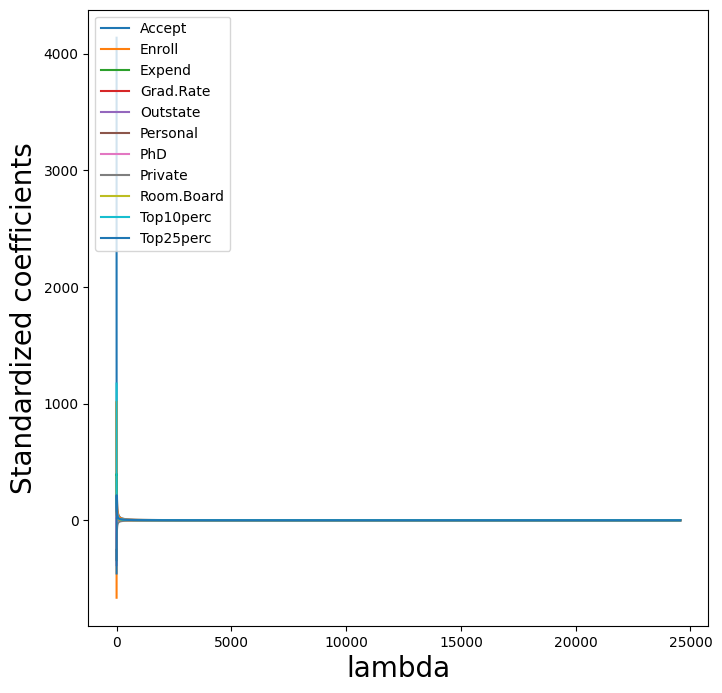

In [1137]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel('lambda', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20) 
ax.legend(loc='upper left');

Given the output, above, it is advantageous to -log transform lambda.

In [1138]:
soln_path_n_log = pd.DataFrame(soln_array.T,
                        columns=X.columns,
                        index=-np.log(lambdas))
soln_path_n_log.index.name = 'negative log(lambda)'
soln_path_n_log.iloc[35:55]

,Accept,Enroll,Expend,Grad.Rate,Outstate,Personal,PhD,Private,Room.Board,Top10perc,Top25perc
negative log(lambda),,,,,,,,,,,
-1.968181,402.136416,347.443903,102.589238,61.146216,21.969574,65.900628,134.287677,-159.754993,61.703730,133.570699,131.244016
-1.735597,478.464014,409.474820,118.187874,70.200289,23.364196,76.265875,151.102008,-186.432180,71.445891,152.808695,148.899012
-1.503012,563.988969,477.027840,134.534661,79.700801,24.262311,86.748766,166.528009,-214.378067,81.905616,172.333899,166.056407
-1.270428,658.300502,548.821198,151.341547,89.528677,24.597957,96.785003,179.292087,-242.534740,92.992882,191.542796,181.822742
-1.037844,760.672158,623.105416,168.344508,99.582420,24.349615,105.730593,188.053294,-269.622272,104.605851,209.872963,195.282739
-0.805259,870.138900,697.737199,185.341535,109.780342,23.519772,112.943073,191.556232,-294.265280,116.620908,226.903013,205.601808
-0.572675,985.607884,770.290414,202.215116,120.049830,22.093975,117.881675,188.803286,-315.161513,128.875050,242.443887,212.123342
-0.340091,1105.981555,838.179893,218.931962,130.307933,19.990731,120.203389,179.215844,-331.259444,141.149049,256.600796,214.437682
-0.107506,1230.272424,898.775834,235.519405,140.442327,17.020175,119.829330,162.751705,-341.905436,153.162418,269.790990,212.404964


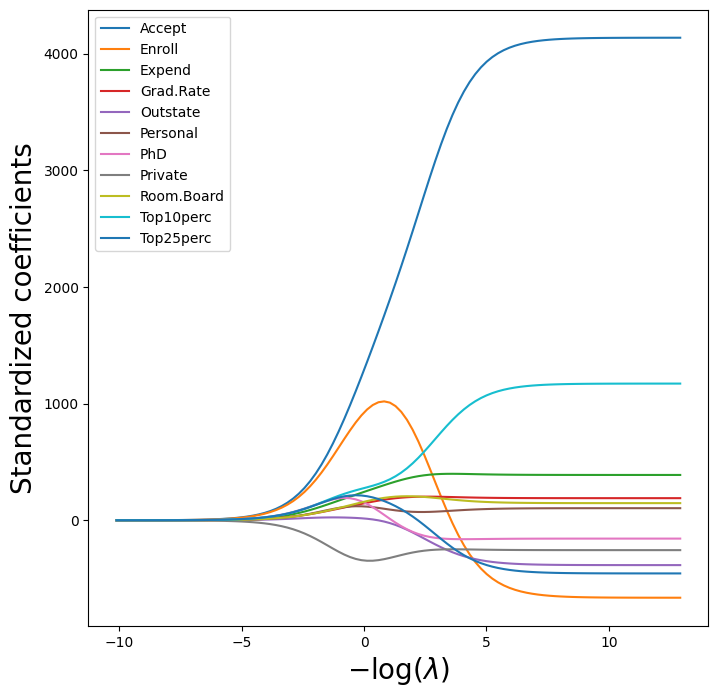

In [1139]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path_n_log.plot(ax=ax, legend=False)
ax.set_xlabel('$-\log(\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20) 
ax.legend(loc='upper left');

I want to see what the minimum MSE is across all lambdas. See the code block, below:

In [1140]:
mse_scores = {}

for i, lam in enumerate(lambdas): 
    ridge = skl.ElasticNet(alpha=lam, l1_ratio=0)
    scaler = StandardScaler(with_mean=True, with_std=True)
    pipe = Pipeline(steps=[('scaler', scaler), ( 'ridge', ridge)]) 
    pipe.fit(X, Y)

    validation = skm.ShuffleSplit(n_splits=1,
                test_size=0.8,
                random_state=0)

    results = skm.cross_validate(ridge,
                                X,
                                Y,
                                scoring='neg_mean_squared_error',
                                cv=validation)
    mse_scores[-results['test_score'][0]] = i

print(f'Lowest MSE lambda: {lambdas[mse_scores[min(mse_scores.keys())]]}\nIndex: {mse_scores[min(mse_scores.keys())]}\nMSE: {min(mse_scores.keys())}')

Lowest MSE lambda: 2.4554080710189502e-06
Index: 99
MSE: 1759737.303935297


As expected, the MSE shrinks proportionally to lambda, as the bias-variance trade-off shifts in the favor of bias, i.e. overfitting. A lambda of nearly 0 reduces the model to an OLS model. The book suggests a GridSearchCV for selection of lambda. 

In [1141]:
param_grid = {'ridge__alpha': lambdas} 

grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=validation,
                        scoring='neg_mean_squared_error')

grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(2....710189502e-06)
,l1_ratio,0
,fit_intercept,True
,precompute,False


This approach selected the same lambda parameter as my approach. I am wiling to bet the implementation is the same. Let's try again with k-fold cross validation.

In [1142]:
K = 5 
kfold = skm.KFold(K,
                random_state=0,
                shuffle=True)

In [1143]:
grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,np.float64(2....710189502e-06)
,l1_ratio,0
,fit_intercept,True
,precompute,False


Again, the same lambda parameter was selected. Plotting MSE against -log($-\log(\lambda)$) will provide a bit more insight into the relationship between the two.

Text(0, 0.5, 'Cross-validated MSE')

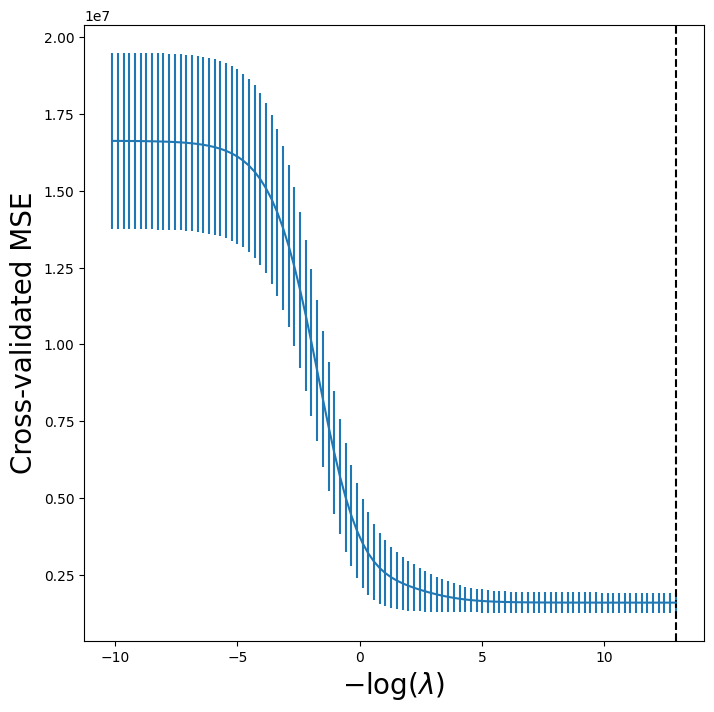

In [1144]:
ridge_fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K)) 

ax.axvline(-np.log(lambdas[mse_scores[min(mse_scores.keys())]]), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20)

Perhaps I made a mistake in my approach, but cross validation with negative MSE scoring does not seem like an effective method for selecting $-\log(\lambda)$. In each case, cross validation selected for a lambda value that minimized MSE, which drives lambda to 0. A zero-lambda ridge regression model reduces to an OLS model, therefore the cross validation methods used are not finding a lambda value that provides an optimal set of model coefficients to prevent overfitting. The Test MSE is calculated, below:

In [1145]:
test_X = test_data[list(training_Cp.selected_state_)]
test_y = test_data['Apps']

In [1146]:
ridge = skl.ElasticNet(alpha=lambdas[mse_scores[min(mse_scores.keys())]], l1_ratio=0)
scaler = StandardScaler(with_mean=True, with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ( 'ridge', ridge)]) 
pipe.fit(X, Y)

test_y_pred = pipe.predict(test_X)
train_y_pred = pipe.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1174803.5877351766	Test MSE: 969922.8379162485


The test MSE is lower than the training MSE, which is suspicious. As I commented on before, I think there may be an issue in my approach, but I haven't been able to find it. 

## Part D

Fit a lasso model on the training set, with λ chosen by cross-validation. Report the test error obtained, along with the number of non-zero coefficient estimates.

In [1147]:
lassoCV = skl.ElasticNetCV(n_alphas=100,
                            l1_ratio=1,
                            cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler), 
('lasso', lassoCV)]) 
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

np.float64(3.8151662975778846)

In [1148]:
lambdas, soln_array = skl.Lasso.path(Xs,
                                    Y,
                                    l1_ratio=1,
                                    n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,
                            columns=X.columns,
                            index=-np.log(lambdas))

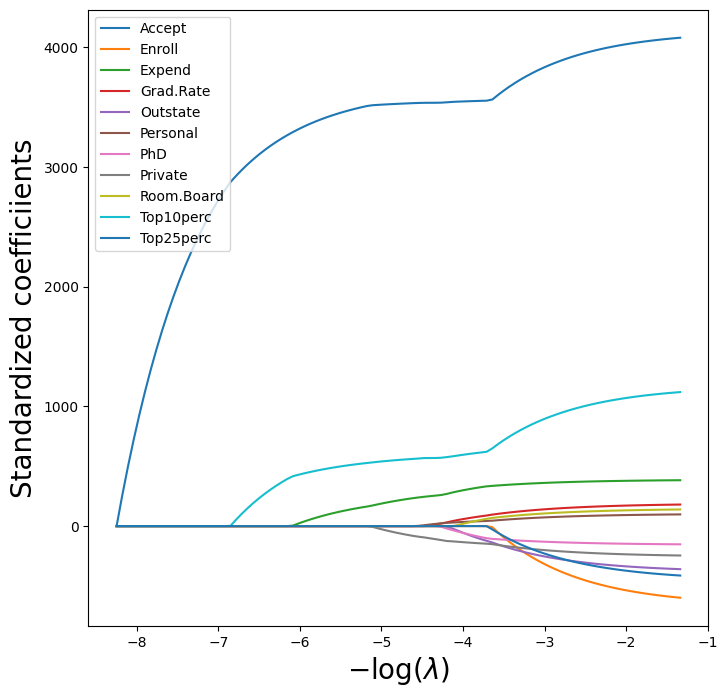

In [1149]:
path_fig, ax = plt.subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Standardized coefficiients', fontsize=20);

In [1150]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(1596321.1411910274)

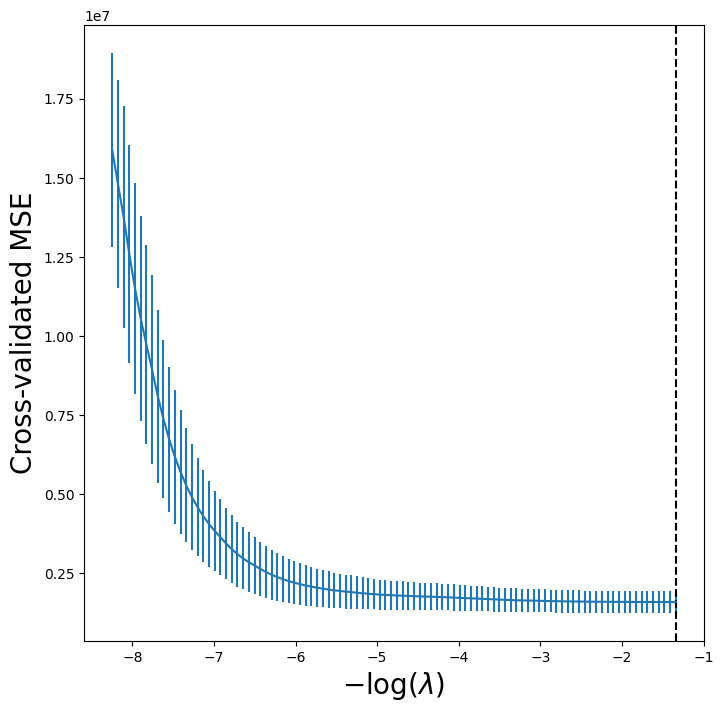

In [1151]:
lassoCV_fig, ax = plt.subplots(figsize=(8,8))

ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20); 

In [1152]:
tuned_lasso.coef_

array([4073.53572531, -596.81320983,  382.86945334,  180.01307209,
       -359.05760966,   97.60820858, -151.90393236, -245.20176134,
        138.95440927, 1117.73130327, -412.1056088 ])

## Part E

Fit a PCR model on the training set, with M chosen by cross-validation. Report the test error obtained, along with the value of M selected by cross-validation.

In [1154]:
from sklearn.decomposition import PCA

In [1155]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()

pipe = Pipeline([('pca', pca), 
                ('linreg', linreg)]) 

pipe.fit(X, Y)
pipe.named_steps['linreg'].coef_

array([ 0.16565058, -0.97969548])

In [1156]:
param_grid = {'pca__n_components': range(1, 20)} 
grid = skm.GridSearchCV(pipe,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)

,estimator,Pipeline(step...egression())])
,param_grid,"{'pca__n_components': range(1, 20)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,11


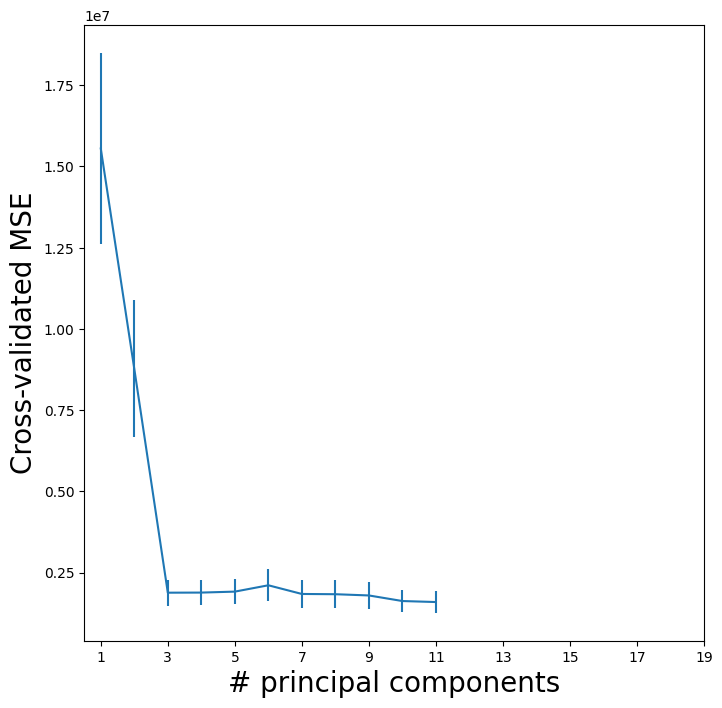

In [1157]:
pcr_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K)) 

ax.set_ylabel('Cross-validated MSE', fontsize=20) 
ax.set_xlabel('# principal components', fontsize=20) 
ax.set_xticks(n_comp[::2]);

In [1158]:
pipe.named_steps['pca'].explained_variance_ratio_

array([0.73909399, 0.14043263])

In [1159]:
pca = PCA(n_components=11)
linreg = skl.LinearRegression()

pipe = Pipeline([('pca', pca), 
                ('linreg', linreg)]) 

pipe.fit(X, Y)

test_y_pred = pipe.predict(test_X)
train_y_pred = pipe.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1174803.5866056092	Test MSE: 969940.9868694985


## Part F

it a PLS model on the training set, with M chosen by cross-validation. Report the test error obtained, along with the value of M selected by cross-validation.

In [1160]:
from sklearn.cross_decomposition import PLSRegression

In [1161]:
pls = PLSRegression(n_components=2,
scale=True)
pls.fit(X, Y)

,n_components,2
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


In [1162]:
param_grid = {'n_components':range(1, 20)}
grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(X, Y)

,estimator,PLSRegression()
,param_grid,"{'n_components': range(1, 20)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,11


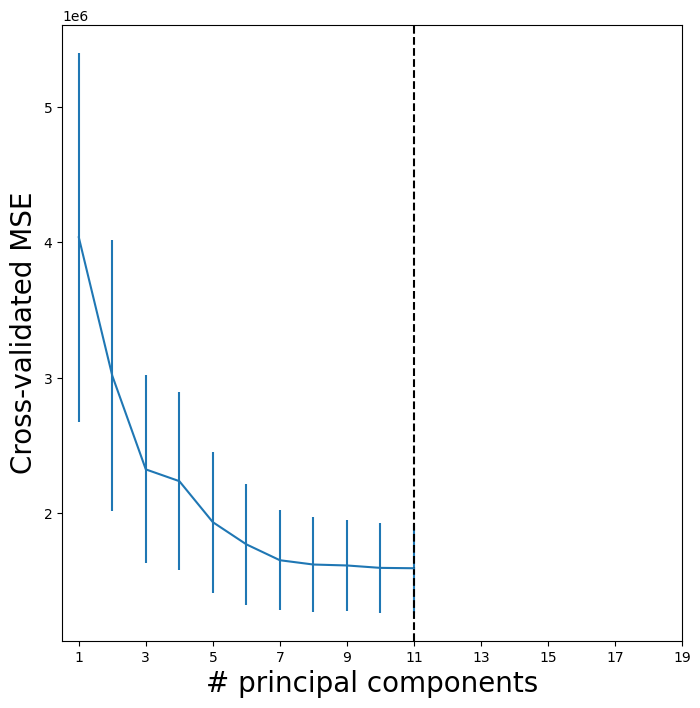

In [1163]:
pls_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
 
ax.axvline(grid.best_estimator_.n_components, c='k', ls= '--')
ax.set_ylabel('Cross-validated MSE', fontsize=20) 
ax.set_xlabel('# principal components', fontsize=20) 
ax.set_xticks(n_comp[::2]);

In [1164]:
pls = PLSRegression(n_components=grid.best_estimator_.n_components,
                        scale=True)
pls.fit(X, Y)

test_y_pred = pls.predict(test_X)
train_y_pred = pls.predict(X)

train_mse = mean_squared_error(y_true=Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 1174803.5866056087	Test MSE: 969940.9868695065


## Part G

Comment on the results obtained. How accurately can we predict the number of college applications received? Is there much difference among the test errors resulting from these five approaches?

# Problem 11

We will now try to predict per capita crime rate in the Boston dataset.

#### Data Set Information:

A data set containing housing values in 506 suburbs of Boston.

crim: per capita crime rate by town.

zn: proportion of residential land zoned for lots over 25,000 sq.ft.

indus: proportion of non-retail business acres per town.

chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

nox: nitrogen oxides concentration (parts per 10 million).

rm: average number of rooms per dwelling.

age: proportion of owner-occupied units built prior to 1940.

dis: weighted mean of distances to five Boston employment centres.

rad: index of accessibility to radial highways.

tax: full-value property-tax rate per $10,000.

ptratio: pupil-teacher ratio by town.

lstat: lower status of the population (percent).

medv: median value of owner-occupied homes in $1000s.

In [1165]:
boston = load_data('Boston')

In [1166]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


## Part A 

Try out some of the regression methods explored in this chapter, such as best subset selection, the lasso, ridge regression, and PCR. Present and discuss results for the approaches that you consider.

**I am interested in trying the both Forward and Backward Stepwise Selection methods, PLS, Ridge Regression, and the Lasso.**

In [1167]:
training_data, test_data = split_data(boston, 65)

print(len(training_data), len(test_data))

328 178


## Both Forward and Backward Stepwise Selection

In [1168]:
design = MS(boston.columns.drop('crim')).fit(boston)
Y = np.array(boston['crim'])
X = design.transform(boston) 
sigma2 = sm.OLS(Y,X).fit().scale
sigma2

np.float64(41.73329329890219)

In [1169]:
neg_Cp = partial(nCp, sigma2)

In [1170]:
strategy = Stepwise.first_peak(design,
                                direction='both',
                                max_terms=len(design.terms))

In [1171]:
boston_Cp = sklearn_selected(sm.OLS,
                            strategy,
                            scoring=neg_Cp)
boston_Cp.fit(boston, Y)
boston_Cp.selected_state_

('lstat', 'medv', 'ptratio', 'rad')

In [1172]:
train_X = training_data[list(boston_Cp.selected_state_)]
train_Y = training_data['crim']

test_X = test_data[list(boston_Cp.selected_state_)]
test_Y = test_data['crim']

In [1173]:
ols = sm.OLS(train_Y, train_X).fit()

test_y_pred = ols.predict(test_X)
train_y_pred = ols.predict(train_X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)

print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 34.206920290424165	Test MSE: 58.025877870469564


## PLS Regression

In [1174]:
pls = PLSRegression(n_components=2,
scale=True)
pls.fit(train_X, train_Y)

,n_components,2
,scale,True
,max_iter,500
,tol,1e-06
,copy,True


In [1175]:
param_grid = {'n_components':range(1, 20)}
grid = skm.GridSearchCV(pls,
                        param_grid,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
grid.fit(train_X, train_Y)

,estimator,PLSRegression()
,param_grid,"{'n_components': range(1, 20)}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,3


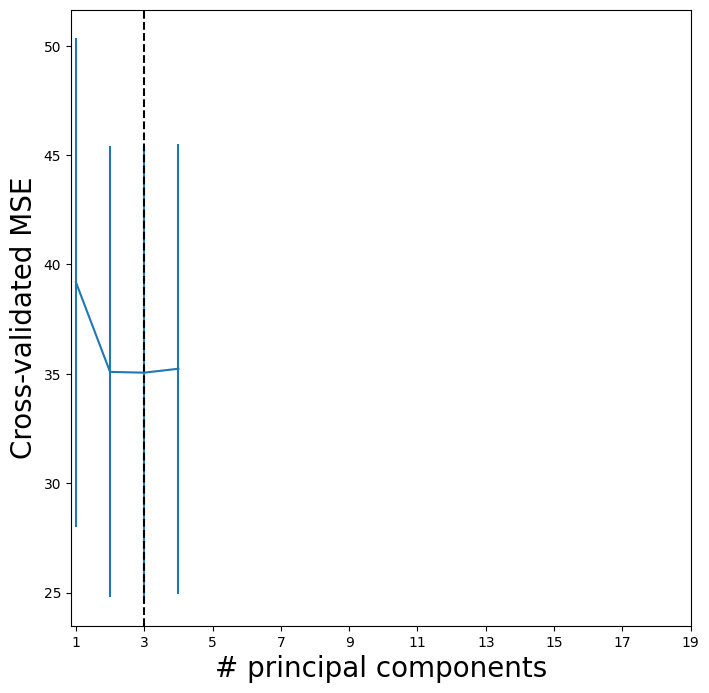

In [1176]:
pls_fig, ax = plt.subplots(figsize=(8,8))
n_comp = param_grid['n_components']

ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
 
ax.axvline(grid.best_estimator_.n_components, c='k', ls= '--')
ax.set_ylabel('Cross-validated MSE', fontsize=20) 
ax.set_xlabel('# principal components', fontsize=20) 
ax.set_xticks(n_comp[::2]);

In [1177]:
pls = PLSRegression(n_components=grid.best_estimator_.n_components,
                        scale=True)
pls.fit(train_X, train_Y)

test_y_pred = pls.predict(test_X)
train_y_pred = pls.predict(train_X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 34.176636329928186	Test MSE: 58.0453962878946


## Ridge Regression

In [1178]:
ridgeCV = skl.ElasticNetCV(alphas=lambdas,
                            l1_ratio=0,
                            cv=kfold)

pipeCV = Pipeline(steps=[('scaler', scaler), 
                         ('ridge', ridgeCV)])

pipeCV.fit(train_X, train_Y)

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,l1_ratio,0
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([3811.3... 3.81135684])


Text(0, 0.5, 'Cross-validated MSE')

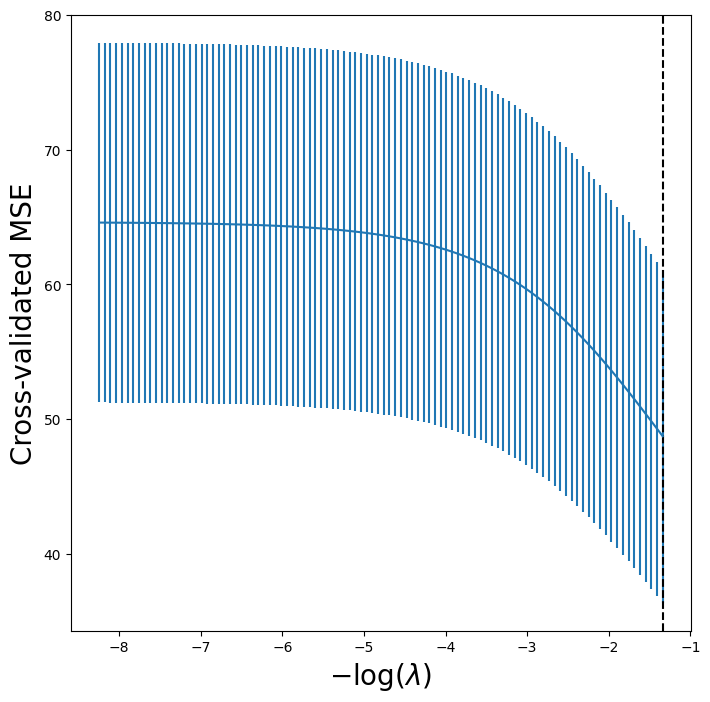

In [1179]:
tuned_ridge = pipeCV.named_steps['ridge']
ridgeCV_fig, ax = plt.subplots(figsize=(8,8))

ax.errorbar(-np.log(lambdas),
            tuned_ridge.mse_path_.mean(1),
            yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))

ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls= '--')
ax.set_xlabel('$-\log(\lambda)$', fontsize=20) 
ax.set_ylabel('Cross-validated MSE', fontsize=20)

In [1180]:
np.min(tuned_ridge.mse_path_.mean(1))

np.float64(48.73077655098181)

In [1181]:
tuned_ridge.coef_

array([ 0.66855087, -0.47435669,  0.29782393,  0.93931383])

In [1182]:
test_y_pred = tuned_ridge.predict(test_X)
train_y_pred = tuned_ridge.predict(train_X)

train_mse = mean_squared_error(y_true=train_Y, y_pred=train_y_pred)
test_mse = mean_squared_error(y_true=test_Y, y_pred=test_y_pred)
print(f'Train MSE: {train_mse}\tTest MSE: {test_mse}')

Train MSE: 280.03663128946056	Test MSE: 273.9822183455081


## The Lasso

## Part B
Propose a model (or set of models) that seem to perform well on this data set, and justify your answer. Make sure that you are evaluating model performance using validation set error, cross-validation, or some other reasonable alternative, as opposed to using training error.

## Part C

Does your chosen model involve all of the features in the data set? Why or why not?